# MobileNetV3-Large Image Classification with OpenVINO

This tutorial demonstrates how to run and optimize the MobileNetV3-Large image classification model with OpenVINO. It classifies images using the ImageNet dataset (1000 classes).

**You will learn:**
- Load MobileNetV3-Large and convert to OpenVINO IR
- Run inference with FP32/INT8 models
- Quantize using NNCF Post-Training Quantization (skipped if quantized model exists)
- Build a Gradio demo with class labels displayed on the image

**Table of contents:**
- [Setup](#Setup)
- [Model Acquisition](#Model-Acquisition)
- [Inference Utilities](#Inference-Utilities)
- [Load OpenVINO Model](#Load-OpenVINO-Model)
- [Run Inference](#Run-Inference)
- [NNCF Quantization](#NNCF-Quantization)
- [Gradio Demo](#Gradio-Demo)

## Setup
<a id="Setup"></a>

Install OpenVINO 2026.0, NNCF, and dependencies.

In [1]:
%pip install -q "openvino>=2026.0.0" "nncf>=2.19.0"
%pip install -q "torch>=2.8" "torchvision>=0.16" onnx tqdm opencv-python gradio matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "utils").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))

import requests
if not (NOTEBOOK_DIR / "notebook_utils.py").exists():
    src = NOTEBOOK_DIR.parent / "yolox-optimization" / "notebook_utils.py"
    if src.exists():
        import shutil
        shutil.copy(src, NOTEBOOK_DIR / "notebook_utils.py")
    else:
        r = requests.get("https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/2026.0/utils/notebook_utils.py")
        (NOTEBOOK_DIR / "notebook_utils.py").write_text(r.text)

from notebook_utils import download_file, device_widget

## Model Acquisition
<a id="Model-Acquisition"></a>

Convert PyTorch MobileNetV3-Large to OpenVINO IR using `ov.convert_model`.

In [3]:
import torch
import openvino as ov
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

MODEL_DIR = Path("model") / "mobilenet_v3_large"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IR_PATH = MODEL_DIR / "mobilenet_v3_large.xml"
QUANTIZED_PATH = MODEL_DIR / "mobilenet_v3_large_int8.xml"

if not IR_PATH.exists():
    print("Converting PyTorch MobileNetV3-Large to OpenVINO IR...")
    pt_model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    pt_model.eval()
    dummy = torch.rand(1, 3, 224, 224)
    ov_model = ov.convert_model(pt_model, example_input=dummy)
    ov.save_model(ov_model, IR_PATH)
    print("Model saved:", IR_PATH)
else:
    print("Model found:", IR_PATH)
    ov_model = ov.Core().read_model(str(IR_PATH))

Model found: model\mobilenet_v3_large\mobilenet_v3_large.xml


## Inference Utilities
<a id="Inference-Utilities"></a>

Import ImageNet preprocessing, top-k postprocessing, and visualization.

In [4]:
from utils.mobilenet_utils import (
    preproc,
    top_k,
    vis_classification,
    get_imagenet_labels,
)

IMAGENET_LABELS = get_imagenet_labels()
INPUT_SIZE = (224, 224)

## Load OpenVINO Model
<a id="Load-OpenVINO-Model"></a>

In [5]:
core = ov.Core()
if 'ov_model' not in dir() or ov_model is None:
    ov_model = core.read_model(IR_PATH)

device = device_widget(default="CPU", description="Device:")
from IPython.display import display
display(device)
compiled_model = core.compile_model(ov_model, device.value)

Dropdown(description='Device:', options=('CPU', 'GPU', 'NPU', 'AUTO'), value='CPU')

## Run Inference on Image
<a id="Run-Inference"></a>

Download a test image and run classification.

In [6]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
IMAGE_PATH = DATA_DIR / "coco.jpg"
if not IMAGE_PATH.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg",
        filename=IMAGE_PATH.name,
        directory=DATA_DIR,
    )

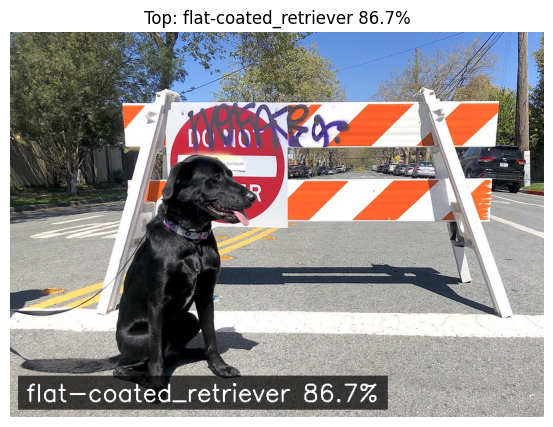

In [7]:
import cv2
import numpy as np

def run_classification(image, model=compiled_model, top_k_count=5, class_names=IMAGENET_LABELS):
    """Run MobileNetV3 classification. Returns (annotated_image, top_results)."""
    if image is None or image.size == 0:
        return None, []
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    tensor = preproc(image, INPUT_SIZE)
    logits = model([tensor])[0]
    results = top_k(logits, class_names, k=top_k_count)
    if not results:
        return image, []
    top_idx, top_label, top_conf = results[0]
    annotated = vis_classification(image, top_label, top_conf * 100)
    return annotated, results

img = cv2.imread(str(IMAGE_PATH))
result_img, top_results = run_classification(img)
if result_img is not None:
    result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
    from matplotlib import pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.imshow(result_rgb)
    plt.axis("off")
    plt.title(f"Top: {top_results[0][1]} {top_results[0][2]*100:.1f}%" if top_results else "Classification")
    plt.show()

## NNCF Post-Training Quantization
<a id="NNCF-Quantization"></a>

Quantize to INT8 only if the quantized model does not already exist.

In [8]:
def get_calibration_images(n=200):
    images = []
    coco128 = NOTEBOOK_DIR.parent / "yolov8-optimization" / "datasets" / "coco128" / "images" / "train2017"
    if coco128.exists():
        for p in sorted(coco128.glob("*.jpg"))[:n]:
            images.append(str(p))
    if len(images) < 50:
        for p in DATA_DIR.glob("*.jpg"):
            images.append(str(p))
        while len(images) < 100 and IMAGE_PATH.exists():
            images.append(str(IMAGE_PATH))
    return images[:n]

calibration_images = get_calibration_images(200)
print(f"Calibration images: {len(calibration_images)}")

Calibration images: 128


In [9]:
if QUANTIZED_PATH.exists():
    print("Quantized model already exists:", QUANTIZED_PATH)
    quantized_model = core.read_model(QUANTIZED_PATH)
    compiled_quantized = core.compile_model(quantized_model, device.value)
else:
    import nncf

    def transform_fn(path):
        img = cv2.imread(path)
        if img is None:
            return np.zeros((1, 3, 224, 224), dtype=np.float32)
        return preproc(img, INPUT_SIZE)

    calibration_dataset = nncf.Dataset(calibration_images, transform_fn)
    quantized_model = nncf.quantize(ov_model, calibration_dataset)
    ov.save_model(quantized_model, QUANTIZED_PATH)
    print("Quantized model saved:", QUANTIZED_PATH)
    compiled_quantized = core.compile_model(quantized_model, device.value)

Quantized model already exists: model\mobilenet_v3_large\mobilenet_v3_large_int8.xml


### INT8 inference

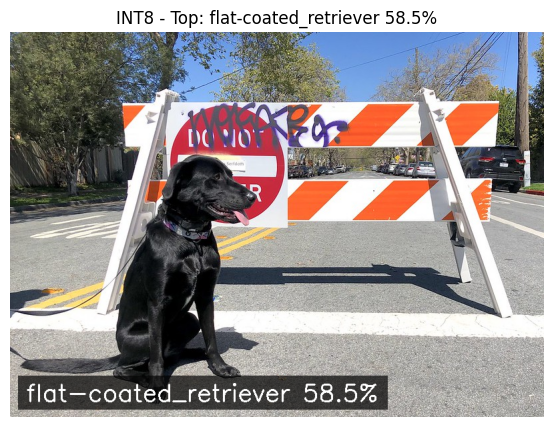

In [10]:
img_int8 = cv2.imread(str(IMAGE_PATH))
result_int8, top_int8 = run_classification(img_int8, model=compiled_quantized)
if result_int8 is not None:
    from matplotlib import pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(result_int8, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"INT8 - Top: {top_int8[0][1]} {top_int8[0][2]*100:.1f}%" if top_int8 else "INT8 Classification")
    plt.show()

In [11]:
import time

def benchmark(model, n_warmup=10, n_iter=50):
    dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)
    for _ in range(n_warmup):
        model([dummy])
    start = time.perf_counter()
    for _ in range(n_iter):
        model([dummy])
    return (time.perf_counter() - start) / n_iter * 1000

fp32_ms = benchmark(compiled_model)
int8_ms = benchmark(compiled_quantized)
print(f"FP32: {fp32_ms:.2f} ms | INT8: {int8_ms:.2f} ms | Speedup: {fp32_ms/int8_ms:.2f}x")

FP32: 2.63 ms | INT8: 1.57 ms | Speedup: 1.67x


## Gradio Demo
<a id="Gradio-Demo"></a>

Interactive demo: upload, webcam, or sample image. Classification label is drawn on the image.

In [12]:
import gradio as gr
from pathlib import Path

_fp32_model = ov_model
_int8_model = core.read_model(QUANTIZED_PATH) if QUANTIZED_PATH.exists() else None
_avail = core.available_devices
_device_choices = ["CPU"] + [d for d in _avail if d != "CPU"]
_precision_choices = ["FP32", "INT8"] if _int8_model is not None else ["FP32"]
_compiled_cache = {}

def get_demo_model(device_name, precision="FP32"):
    model = _int8_model if precision == "INT8" and _int8_model is not None else _fp32_model
    key = (device_name, precision)
    if key not in _compiled_cache:
        try:
            _compiled_cache[key] = core.compile_model(model, device_name)
        except Exception:
            _compiled_cache[key] = core.compile_model(model, "CPU")
    return _compiled_cache[key]

def _ensure_numpy(img):
    if img is None:
        return None
    path = None
    if isinstance(img, np.ndarray):
        out = img if len(img.shape) == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        if len(out.shape) == 3 and out.shape[-1] == 3:
            out = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        return out
    if isinstance(img, str) and len(img) > 0:
        path = img
    elif isinstance(img, (list, tuple)) and len(img) > 0:
        it = img[0]
        path = it if isinstance(it, str) else getattr(it, "name", getattr(it, "path", None))
    elif hasattr(img, "name"):
        path = getattr(img, "name", None)
    elif hasattr(img, "path"):
        path = getattr(img, "path", None)
    elif isinstance(img, dict):
        path = img.get("path") or img.get("name")
        if path is None and "image" in img:
            im = img["image"]
            if im is None:
                return None
            out = np.array(im)
            if len(out.shape) == 3 and out.shape[-1] == 3:
                out = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
            return out
    if path and not callable(path):
        path = str(Path(path))
        arr = cv2.imread(path)
        if arr is not None:
            return arr
    return None

def classify_and_show(image, device_name, precision):
    img = _ensure_numpy(image)
    if img is None:
        return None, ""
    try:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        # _ensure_numpy returns BGR; no extra conversion needed
        model = get_demo_model(device_name, precision)
        result_img, top_res = run_classification(img, model=model, class_names=IMAGENET_LABELS)
        label_txt = f"{top_res[0][1]} {top_res[0][2]*100:.1f}%" if (top_res and len(top_res)) else ""
        rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB) if result_img is not None else None
        return rgb, label_txt
    except Exception as e:
        print(f"Classification error: {e}")
        return None, f"Error: {e}"

with gr.Blocks(title="MobileNetV3-Large Classification") as demo:
    gr.Markdown("# MobileNetV3-Large Image Classification (ImageNet)")
    gr.Markdown("Choose **FP32** for better accuracy; **INT8** for faster inference (may misclassify some images).")
    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(sources=["upload", "webcam"], label="Image (upload, drop, or webcam)", height=380)
            _sample_paths = [[str(IMAGE_PATH)]] if IMAGE_PATH.exists() else []
            if _sample_paths:
                gr.Examples(_sample_paths, inputs=inp, label="Sample (click to load)", run_on_click=False)
        with gr.Column(scale=1):
            out = gr.Image(label="Classification result", height=380)
            out_label = gr.Textbox(label="Classification", placeholder="Top class will appear here", lines=1)
    with gr.Row():
        run_btn = gr.Button("Run Classification", variant="primary")
        device_dropdown = gr.Dropdown(choices=_device_choices, value="CPU", label="Device")
        precision_dropdown = gr.Dropdown(choices=_precision_choices, value="FP32", label="Precision")
    gr.Markdown("Upload, drop, or capture from webcam. Click a sample to load it. The top ImageNet class is shown below the result image.")

    run_btn.click(classify_and_show, [inp, device_dropdown, precision_dropdown], [out, out_label])

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
